In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from datetime import datetime
from geopy.distance import geodesic
from sklearn.cluster import KMeans

In [2]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [3]:
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    km = 6371 * c
    return km

In [7]:
def categorize_location(city_pop):
    if city_pop > 50000:
        return 1
    elif city_pop > 10000:
        return 2
    else:
        return 3

In [8]:
# Function to compute distance between merchant and transaction locations
def calculate_distance_between_locations(lat1, long1, lat2, long2):
    return geodesic((lat1, long1), (lat2, long2)).kilometers


In [12]:
def data_processing(df_path):
    df = pd.read_csv(df_path)
    df.drop(df.columns[0], axis=1, inplace=True)
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    df['year'] = df['trans_date_trans_time'].dt.year
    df['month'] = df['trans_date_trans_time'].dt.month
    df['day'] = df['trans_date_trans_time'].dt.day
    df['time'] = df['trans_date_trans_time'].dt.time
    
    df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')
    
    # Ensure 'dob' is in datetime format
    df['dob'] = pd.to_datetime(df['dob'])

    # Calculate age and create a new 'age' column
    df['age'] = df['dob'].apply(calculate_age)
    
    # Calculate distance and create a new 'distance_km' column
#     df['dist_client_merch'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)
    # Apply the function to create a new feature
    df['distance_to_merchant'] = df.apply(
        lambda row: calculate_distance_between_locations(row['lat'], row['long'], row['merch_lat'], row['merch_long']),
        axis=1
    )
    
    df['location_type'] = df['city_pop'].apply(categorize_location)
    
    # Apply K-Means clustering
    coords = df[['lat', 'long']]
    kmeans = KMeans(n_clusters=5, random_state=0).fit(coords)
    df['location_cluster'] = kmeans.labels_
    
    le = LabelEncoder()
    df['le_gender'] = le.fit_transform(df['gender'])
    
    te = TargetEncoder()
    le_job = le.fit_transform(df['job'])
    df['le_job'] = le_job
    le_street = le.fit_transform(df['street'])
    df['le_street'] = le_street
    le_merchant = le.fit_transform(df['merchant'])
    df['le_merchant'] = le_merchant
    le_city = le.fit_transform(df['city'])
    df['le_city'] = le_city
    le_state = le.fit_transform(df['state'])
    le_category = le.fit_transform(df['category'])
    df['le_category'] = le_category
    
    return df

In [13]:
df = data_processing('../fraudTrain.csv')

In [14]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,le_job,le_street,le_merchant,le_city,le_category
771129,2019-11-25 21:09:38,6011693194885790,"fraud_Feil, Hilpert and Koss",food_dining,39.38,Victoria,Fleming,F,2807 Parker Station Suite 080,Stanchfield,MN,55080,45.6675,-93.2433,2607,"Lecturer, further education",1995-12-04,a3f472a217e0a18b32254af290a65bb7,1353877778,45.965344,-94.204932,0,2019,11,25,1900-01-01 21:09:38,28,81.74009,3,2,0,265,281,170,771,1


In [36]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'le_street', 'job', 'first', 'last', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num','dob'
]

# Create a new DataFrame by dropping the specified columns
df_1 = df.drop(columns=columns_to_drop)

,amt,zip,lat,long,city_pop,dob,unix_time,merch_lat,merch_long,is_fraud,year,month,day,age,distance_to_merchant,location_type,location_cluster,le_gender,le_job,le_merchant,le_city,le_category
124774,30.06,49854,46.0062,-86.2555,6469,1979-04-12,1375558216,46.259614,-85.314035,0,2020,8,3,45,78.016056,3,4,0,462,60,449,7


In [37]:
df_test = data_processing('../fraudTest.csv')

In [41]:
df_2 = df_test.drop(columns=columns_to_drop)

In [42]:
X = df_1.drop(columns=['is_fraud'])  # Features
y = df_1['is_fraud'] 

In [34]:
df_2.dtypes

amt                            float64
zip                              int64
lat                            float64
long                           float64
city_pop                         int64
dob                     datetime64[ns]
unix_time                        int64
merch_lat                      float64
merch_long                     float64
is_fraud                         int64
year                             int32
month                            int32
day                              int32
age                              int64
distance_to_merchant           float64
location_type                    int64
location_cluster                 int32
le_gender                        int64
le_job                           int64
le_merchant                      int64
le_city                          int64
le_category                      int64
dtype: object

In [43]:
X_test_actual = df_2.drop(columns=['is_fraud'])  # Features
y_test_actual = df_2['is_fraud'] 

In [20]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


In [65]:
from sklearn.model_selection import train_test_split

X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(X, y, test_size=0.2, random_state=40)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [22]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

In [39]:
rf.fit(X, y)

RandomForestClassifier()

In [44]:
y_pred_rf = rf.predict(X_test_actual)
y_prob_rf = rf.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.997372772930204
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.84      0.40      0.54      2145

    accuracy                           1.00    555719
   macro avg       0.92      0.70      0.77    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.956617433551502


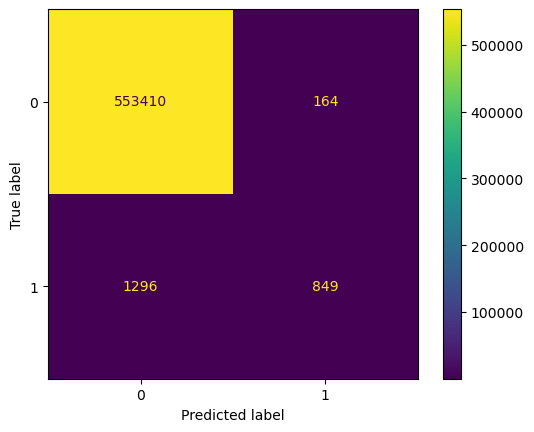

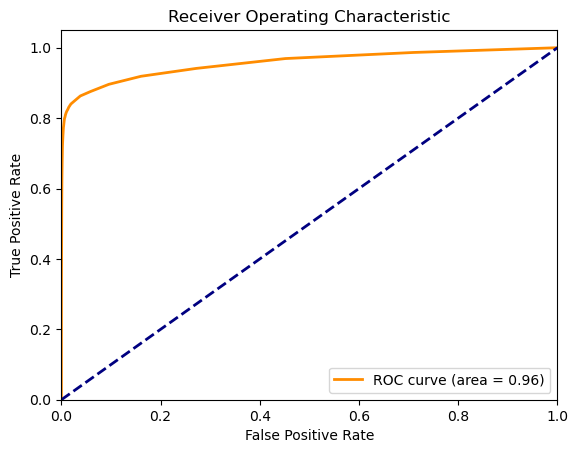

In [45]:
measure_metrics(y_test_actual, y_pred_rf, y_prob_rf)

## Balancing

In [66]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42, sampling_strategy = 'minority')

# Resample the dataset
X_train_smote, y_train_smote = smote.fit_resample(X_train_unbalanced, y_train_unbalanced)

### Random Forest

In [51]:
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [52]:
y_pred_rf_smote = rf_smote.predict(X_test_actual)
y_prob_rf_smote = rf_smote.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9961401355721147
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.50      0.14      0.22      2145

    accuracy                           1.00    555719
   macro avg       0.75      0.57      0.61    555719
weighted avg       0.99      1.00      1.00    555719

ROC AUC Score: 0.907149897639516


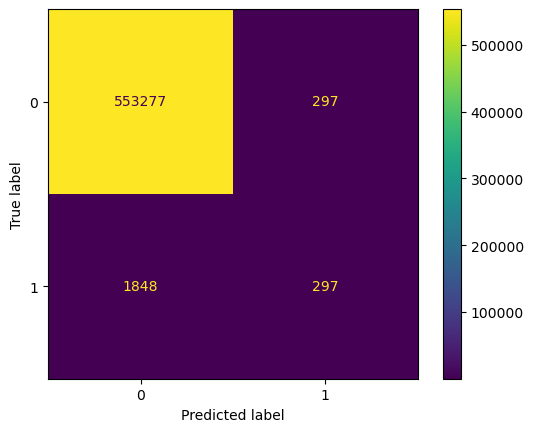

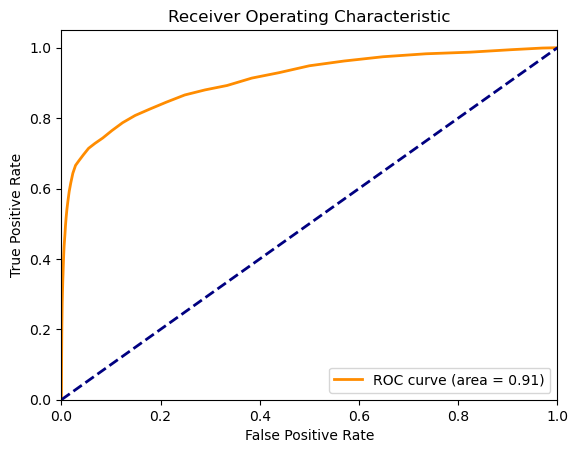

In [53]:
measure_metrics(y_test_actual, y_pred_rf_smote, y_prob_rf_smote)

#### Random Forest -

In [62]:
importances_rf = rf_smote.feature_importances_

# Select the top n features or based on a threshold
n_features = 22  # You can also use a threshold approach
indices = np.argsort(importances_rf)[::-1]
selected_features_rf = indices[:n_features]

In [63]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_rf
})

In [64]:
feature_importance_rf.sort_values(by='Importance', ascending=True)

,Feature,Importance
8,year,0.002644
13,location_type,0.004335
15,le_gender,0.006331
14,location_cluster,0.006435
12,distance_to_merchant,0.014198
6,merch_lat,0.016693
7,merch_long,0.017880
9,month,0.017886
1,zip,0.018722
3,long,0.018846


### XGBoost

In [67]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [70]:
y_pred_xgb_smote_train = xgb_model.predict(X_test_unbalanced)
y_prob_xgb_smote_train = xgb_model.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.987363834422658
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257821
           1       0.30      0.91      0.46      1514

    accuracy                           0.99    259335
   macro avg       0.65      0.95      0.73    259335
weighted avg       1.00      0.99      0.99    259335

ROC AUC Score: 0.948994429726743


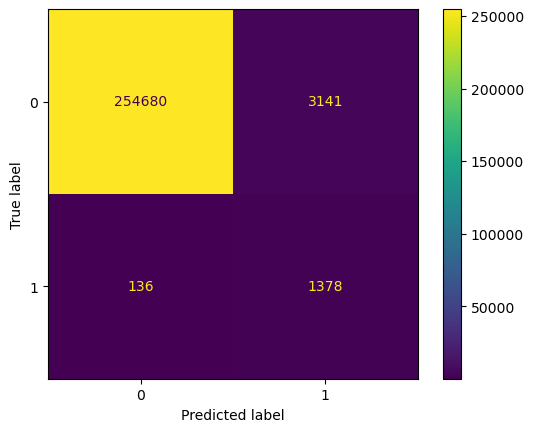

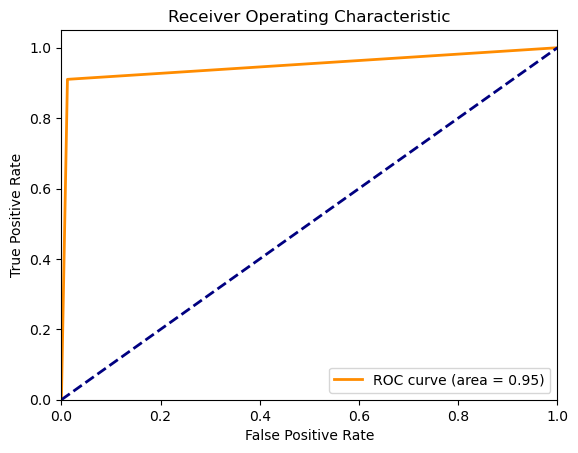

In [71]:
measure_metrics(y_test_unbalanced, y_pred_xgb_smote_train, y_pred_xgb_smote_train)

In [68]:
y_pred_xgb_smote_test = xgb_model.predict(X_test_actual)
y_prob_xgb_smote_test = xgb_model.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.8095602273811044
              precision    recall  f1-score   support

           0       1.00      0.81      0.89    553574
           1       0.02      0.78      0.03      2145

    accuracy                           0.81    555719
   macro avg       0.51      0.79      0.46    555719
weighted avg       1.00      0.81      0.89    555719

ROC AUC Score: 0.8742972609528843


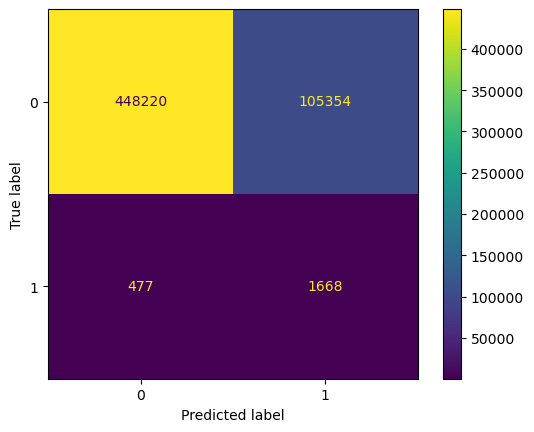

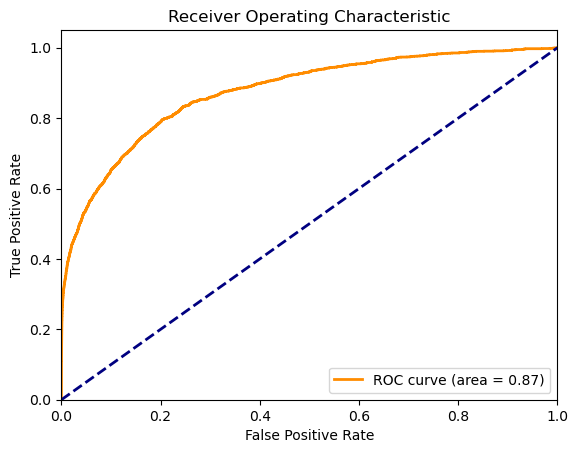

In [69]:
measure_metrics(y_test_actual, y_pred_xgb_smote_test, y_prob_xgb_smote_test)

In [76]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0]
}


In [77]:
xgb_model_tune = xgb.XGBClassifier()

#### Scoring Precision

In [78]:
from sklearn.model_selection import RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='precision', cv=2, verbose=2, 
                                   random_state=42)



In [79]:
xgb_random_search.fit(X,y)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   4.5s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   4.2s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   2.4s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   2.3s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   5.2s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.4, learning_rate=0.01, max_depth=9, n_estimators=100, reg_alpha=0, reg_lambda=0, subsample=0.9; total time=   2.1s
[CV] END colsample_bytree=0.7, gamma=0.4, learning_rate=0.3, max_depth=9, n_estimators=200, reg_alpha=0.5, reg_lambda=1.0, subsample=0.6; total time=   3.3s
[CV] END colsample_bytree=0.7, gamma=0.4, learning_rate=0.3, max_depth=9, n_estimators=200, reg_alpha=0.5, reg_lambda=1.0, subsample=0.6; total time=   3.2s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.1, max_depth=10, n_estimators=300, reg_alpha=0, reg_lambda=0.1, subsample=0.8; total time=   4.3s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.1, max_depth=10, n_estimators=300, reg_alpha=0, reg_lambda=0.1, subsample=0.8; total time=   4.7s
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=400, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   6.8s
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.01, 

[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8; total time=   9.3s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8; total time=   9.6s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=8, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=   7.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=8, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=   8.2s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.15, max_depth=5, n_estimators=500, reg_alpha=0.5, reg_lambda=0.1, subsample=0.7; total time=   6.2s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.15, max_depth=5, n_estimators=500, reg_alpha=0.5, reg_lambda=0.1, subsample=0.7; total time=   6.2s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.1, m

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, reg_alpha=1.0, reg_lambda=0.5, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.2, max_depth=10, n_estimators=100, reg_alpha=0.1, reg_lambda=0, subsample=1.0; total time=   2.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.2, max_depth=10, n_estimators=100, reg_alpha=0.1, reg_lambda=0, subsample=1.0; total time=   2.3s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.2, max_depth=5, n_estimators=400, reg_alpha=1.0, reg_lambda=0.5, subsample=0.9; total time=   5.1s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.2, max_depth=5, n_estimators=400, reg_alpha=1.0, reg_lambda=0.5, subsample=0.9; total time=   5.8s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.9; total time=   2.7s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.15, 

[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.3, max_depth=4, n_estimators=300, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   3.1s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.3, max_depth=4, n_estimators=300, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   3.0s
[CV] END colsample_bytree=1.0, gamma=0.4, learning_rate=0.05, max_depth=7, n_estimators=100, reg_alpha=0.1, reg_lambda=0.1, subsample=0.6; total time=   1.8s
[CV] END colsample_bytree=1.0, gamma=0.4, learning_rate=0.05, max_depth=7, n_estimators=100, reg_alpha=0.1, reg_lambda=0.1, subsample=0.6; total time=   1.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.15, max_depth=4, n_estimators=400, reg_alpha=0.5, reg_lambda=0, subsample=0.9; total time=   3.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.15, max_depth=4, n_estimators=400, reg_alpha=0.5, reg_lambda=0, subsample=0.9; total time=   3.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_de

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='precision', verbose=2)

In [86]:
xgb_random_search.best_params_rams_rams_rams_rams_

{'subsample': 0.8,
 'reg_lambda': 0.1,
 'reg_alpha': 0.1,
 'n_estimators': 100,
 'max_depth': 8,
 'learning_rate': 0.01,
 'gamma': 0,
 'colsample_bytree': 0.8}

In [94]:
y_pred_xgb_test_tuned_precision = xgb_random_search.predict(X_test_actual)
y_prob_xgb_test_tuned_precision = xgb_random_search.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9968995121635215
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       1.00      0.20      0.33      2145

    accuracy                           1.00    555719
   macro avg       1.00      0.60      0.66    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9819290338485605


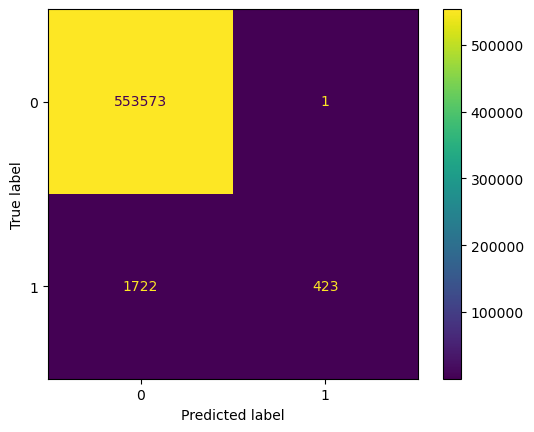

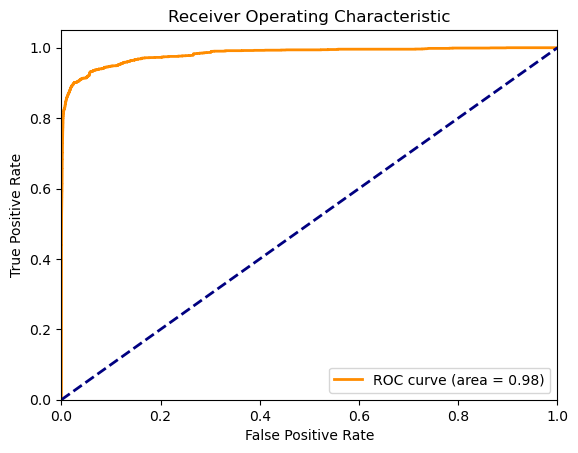

In [95]:
measure_metrics(y_test_actual, y_pred_xgb_test_tuned_precision, y_prob_xgb_test_tuned_precision)

#### Scoring in Recall (balanced)

In [90]:
xgb_random_search_balanced_recall = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='recall', cv=2, verbose=2, 
                                   random_state=42)

In [85]:
xgb_random_search_recall.fit(X,y)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   4.6s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   4.7s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   2.7s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   5.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   4.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   5.0s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=   5.6s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=   5.7s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=8, n_e

[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   3.5s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=   8.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=   8.6s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   6.0s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   5.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=1.0, subsample=0.9; total time=   7.4s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05

[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   3.1s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   4.3s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   4.7s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   3.2s
[CV] END colsample_bytree=0.6, gamma=0.4, learning_rate=0.05, max_

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           random_state=None, ...),
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

In [92]:
y_pred_xgb_test_tuned_recall = xgb_random_search_recall.predict(X_test_actual)
y_prob_xgb_test_tuned_recall = xgb_random_search_recall.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9313016110660244
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.03      0.56      0.06      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.74      0.51    555719
weighted avg       0.99      0.93      0.96    555719

ROC AUC Score: 0.8591523382664223


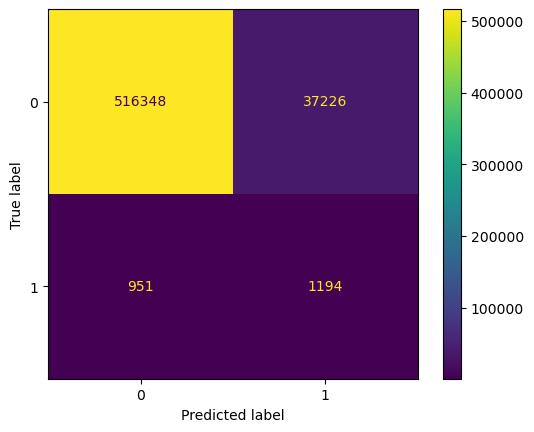

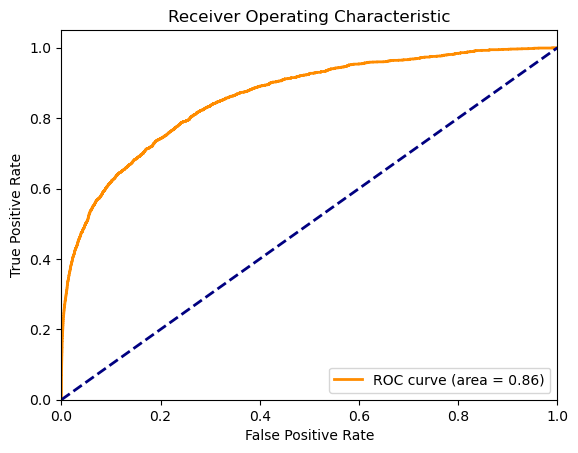

In [93]:
measure_metrics(y_test_actual, y_pred_xgb_test_tuned_recall, y_prob_xgb_test_tuned_recall)

In [ ]:
#### Scoring in 

#### Scoring in Recall (balanced)

In [84]:
xgb_random_search_smote_recall = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='recall', cv=2, verbose=2, 
                                   random_state=42)

In [91]:
xgb_random_search_recall.fit(X_train_smote, y_train_smote)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   6.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   6.4s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   3.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   8.0s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   6.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   6.9s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=  10.0s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=  10.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   4.2s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   4.1s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=8, n_e

[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   7.0s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  16.5s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  15.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   8.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   8.1s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=1.0, subsample=0.9; total time=  10.3s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05

[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   3.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   4.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   7.8s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   7.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   4.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   4.1s
[CV] END colsample_bytree=0.6, gamma=0.4, learning_rate=0.05, max_

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           random_state=None, ...),
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

In [98]:
y_pred_xgb_smote_test_tuned_recall = xgb_random_search_smote_recall.predict(X_test_actual)
y_prob_xgb_smote_test_tuned_recall = xgb_random_search_smote_recall.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9313016110660244
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.03      0.56      0.06      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.74      0.51    555719
weighted avg       0.99      0.93      0.96    555719

ROC AUC Score: 0.8591523382664223


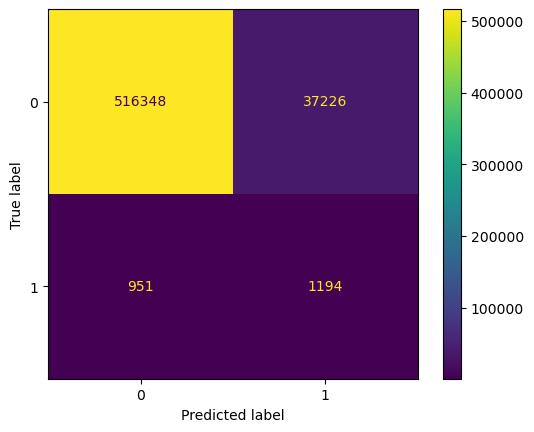

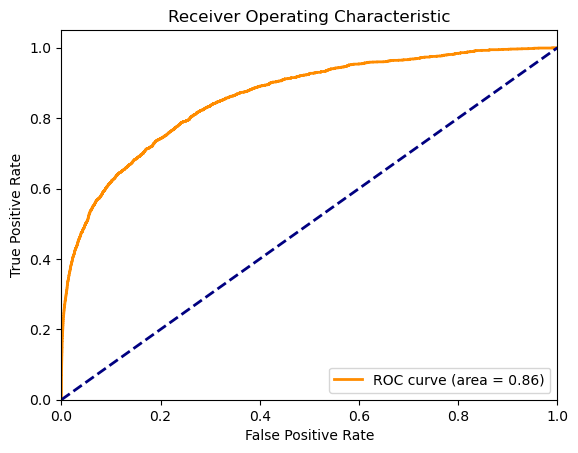

In [99]:
measure_metrics(y_test_actual, y_pred_xgb_smote_test_tuned_recall, y_prob_xgb_smote_test_tuned_recall)